<a href="https://colab.research.google.com/github/AngeNana23/Assignment-10/blob/main/Assignment10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://colab.research.google.com/drive/16VgF5ozNYf1mUBcwH8eki19hKuJI6QOd?usp=sharing

#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


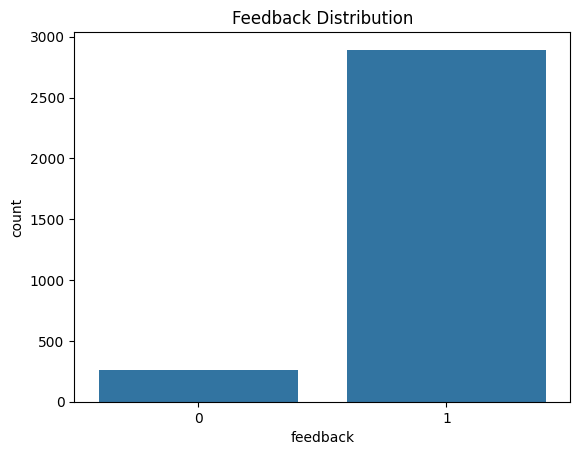

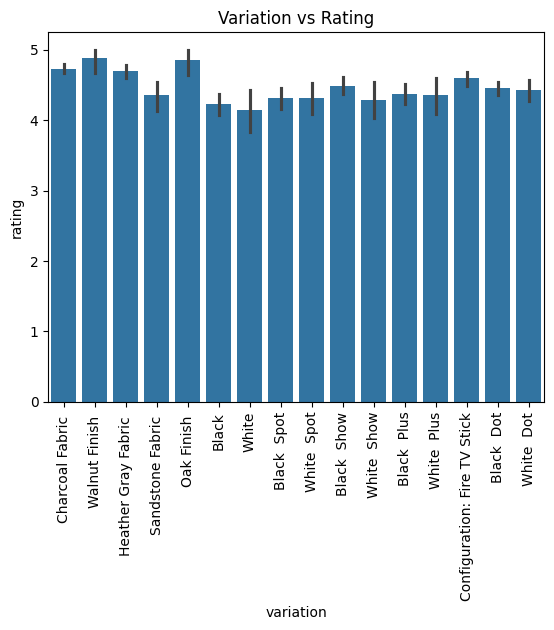

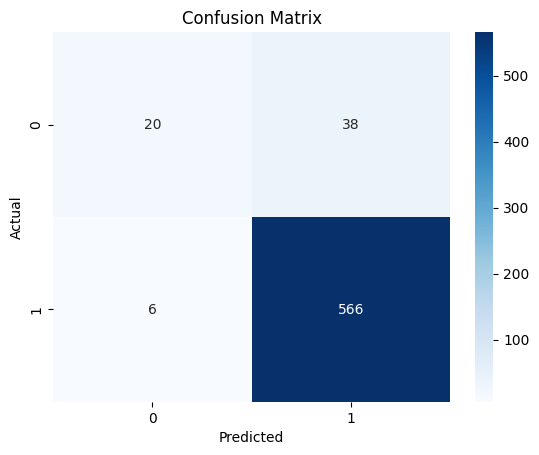

              precision    recall  f1-score   support

           0       0.77      0.34      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.85      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



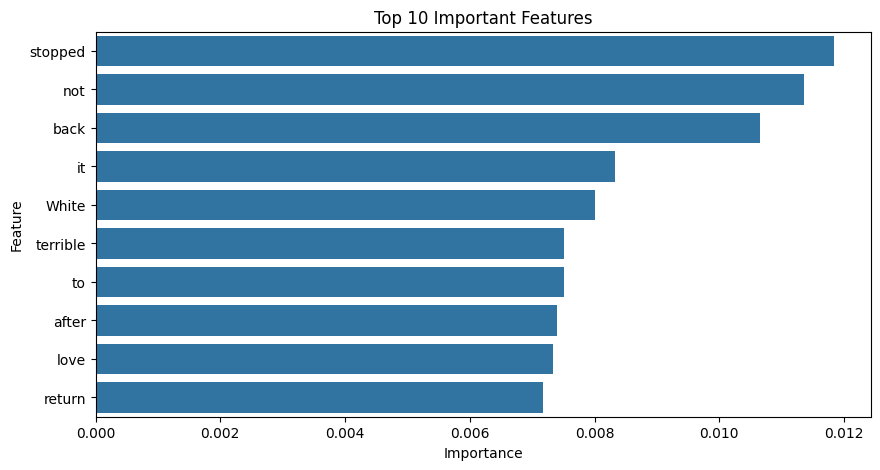

The sentiment of the new review is: Positive


In [8]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest

# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive

df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')


# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

sns.countplot(x='feedback', data=df)
plt.title("Feedback Distribution")
plt.show()


# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

sns.barplot(x='variation', y='rating', data=df)
plt.xticks(rotation=90)
plt.title("Variation vs Rating")
plt.show()


# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

df = df.drop(['date', 'rating'], axis=1)


# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

variation_encoded = pd.get_dummies(df['variation'], drop_first=True)
df = pd.concat([df, variation_encoded], axis=1)
df = df.drop('variation', axis=1)


# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

# FIX: Handle missing text values
df['verified_reviews'] = df['verified_reviews'].fillna('')

vectorizer = CountVectorizer()
text_features = vectorizer.fit_transform(df['verified_reviews'])


# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

text_df = pd.DataFrame(
    text_features.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df = df.drop('verified_reviews', axis=1)
df = pd.concat([df.reset_index(drop=True), text_df.reset_index(drop=True)], axis=1)


# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

# Ensure y is a single Series/1D array.
# The kernel state for y_test implies df['feedback'] resulted in a DataFrame with
# two 'feedback' columns. This selects the first one to avoid 'multilabel-indicator' error.
if isinstance(df['feedback'], pd.DataFrame):
    y = df['feedback'].iloc[:, 0]
else:
    y = df['feedback']

X = df.drop('feedback', axis=1)


# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

print(classification_report(y_test, y_pred))


# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 10 Important Features")
plt.show()


# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

def predict_sentiment(review_text):
    review_vector = vectorizer.transform([review_text]).toarray()

    # Create a DataFrame from the new review vector, ensuring columns match X
    review_df = pd.DataFrame(review_vector, columns=vectorizer.get_feature_names_out())

    # Align columns with the training data X, filling missing columns with 0
    # This handles cases where the new review might not contain all words from training, or vice-versa for dummy variables
    missing_cols_in_review = set(X.columns) - set(review_df.columns)
    for c in missing_cols_in_review:
        review_df[c] = 0
    review_df = review_df[X.columns] # Ensure the order of columns is the same as X

    prediction = model.predict(review_df)[0]

    return "Positive" if prediction == 1 else "Negative"


# Example usage of your prediction function:
new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")

In [5]:
print(df.head())
print(df.columns)

   feedback  Black  Dot  Black  Plus  Black  Show  Black  Spot  \
0         1       False        False        False        False   
1         1       False        False        False        False   
2         1       False        False        False        False   
3         1       False        False        False        False   
4         1       False        False        False        False   

   Charcoal Fabric   Configuration: Fire TV Stick  Heather Gray Fabric   \
0              True                         False                 False   
1              True                         False                 False   
2             False                         False                 False   
3              True                         False                 False   
4              True                         False                 False   

   Oak Finish   Sandstone Fabric   ...  youtube  yr  yrs  yup  zero  zigbee  \
0        False              False  ...        0   0    0    0     0      

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


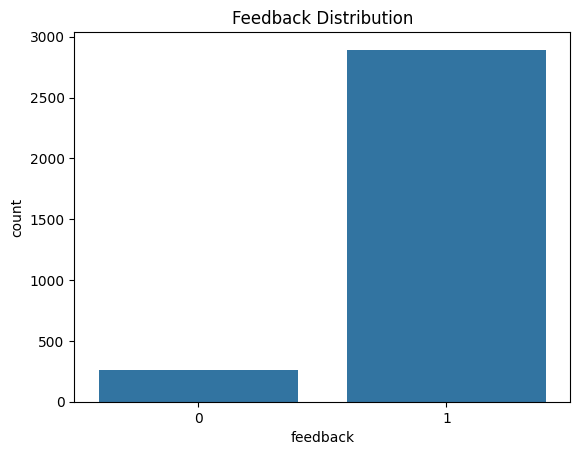

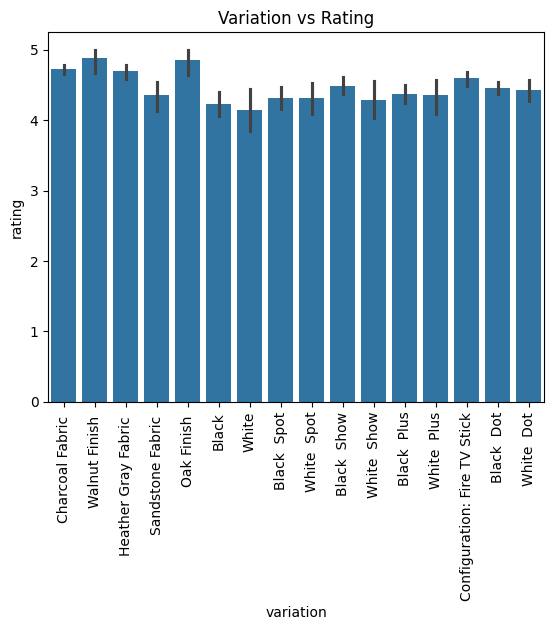

Confusion Matrix:
 [[ 29  29]
 [ 27 545]]

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.50      0.51        58
           1       0.95      0.95      0.95       572

    accuracy                           0.91       630
   macro avg       0.73      0.73      0.73       630
weighted avg       0.91      0.91      0.91       630

Training Accuracy: 0.9345238095238095
Testing Accuracy: 0.9111111111111111
Model performance is GOOD / balanced


In [13]:
# Task 1: Import Libraries and Dataset

# Hint: You need to import libraries like pandas, numpy, matplotlib, seaborn, etc.
# Don't forget to mount Google Drive and load the CSV file using pandas.
# Use `pd.read_csv()` to load the data into a pandas DataFrame.

# TODO: Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report


# TODO: Mount Google Drive

drive.mount('/content/drive')


# TODO: Load the dataset into a DataFrame and preview the first few rows.

df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')
df.head()


# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.

# TODO: Visualize the distribution of feedback (positive/negative)

sns.countplot(x='feedback', data=df)
plt.title("Feedback Distribution")
plt.show()


# TODO: Visualize the relationship between product variation and feedback

sns.barplot(x='variation', y='rating', data=df)
plt.xticks(rotation=90)
plt.title("Variation vs Rating")
plt.show()


# TODO: Drop irrelevant columns ('date', 'rating')

df = df.drop(['date', 'rating'], axis=1)


# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# TODO: Perform one-hot encoding on the 'variation' column

variation_encoded = pd.get_dummies(df['variation'], drop_first=True)
df = pd.concat([df, variation_encoded], axis=1)
df = df.drop('variation', axis=1)


# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.
# After transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# FIX: Handle missing text values
df['verified_reviews'] = df['verified_reviews'].fillna('')

# TODO: Tokenize the 'verified_reviews' column using CountVectorizer

vectorizer = CountVectorizer()
text_features = vectorizer.fit_transform(df['verified_reviews'])

text_df = pd.DataFrame(
    text_features.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df = df.drop('verified_reviews', axis=1)
df = pd.concat([df.reset_index(drop=True), text_df.reset_index(drop=True)], axis=1)


# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

# TODO: Split the data into training and testing sets

X = df.drop('feedback', axis=1)
# Ensure y is a single Series/1D array.
# If df['feedback'] results in a DataFrame with multiple 'feedback' columns,
# this selects the first one to avoid 'multilabel-indicator' error.
if isinstance(df['feedback'], pd.DataFrame):
    y = df['feedback'].iloc[:, 0]
else:
    y = df['feedback']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

# TODO: Define and train a Random Forest Classifier
# Add hyperparameters to mitigate overfitting, such as max_depth and min_samples_leaf

model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


# Hint: Use the `predict()` method to generate predictions for the test data.
# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.

# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
# Compare the results and discuss if the model is overfitting or underfitting.

# TODO: Compare training and testing accuracy and discuss model performance

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

if train_acc > test_acc + 0.05:
    print("Model is OVERFITTING")
else:
    print("Model performance is GOOD / balanced")